## Imports

In [1]:
import pandas as pd
from google.colab import userdata, drive
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


## Extract Data

### 88 samples from judge evaluation

In [3]:
sample_llm_judge_evaluation_df = pd.read_csv("/content/drive/My Drive/Mestrado/Dissertação/mimic-iv-ext-cardiac-disease/processed/audit_sample_extraction_result.csv")
sample_llm_judge_evaluation_df.head()

,judge_score,tp,fp,fn,justification,main_category,nct_id
0,5.0,6.0,0.0,0.0,The extracted inclusion and exclusion lists ex...,NaN,NCT06423625
1,5.0,2.0,0.0,0.0,The extracted inclusion criteria exactly match...,NaN,NCT00090259
2,3.0,10.0,1.0,1.0,One inclusion criterion (Mini-Mental Assessmen...,Omission,NCT05625269
3,1.0,0.0,0.0,18.0,The extracted inclusion and exclusion criteria...,Omission,NCT02394470
4,5.0,15.0,0.0,0.0,The extracted inclusion and exclusion criteria...,NaN,NCT00287209


In [4]:
sample_llm_judge_evaluation_df.count()

,0
judge_score,88
tp,88
fp,88
fn,88
justification,88
main_category,14
nct_id,88


### 88 samples for human evaluation

In [5]:
gold_standard_evaluation_df = pd.read_excel("/content/drive/My Drive/Mestrado/Dissertação/evaluate_gold_standard.xlsx")
gold_standard_evaluation_df.head()

,nct_id,official_title,eligibility_criteria,inclusion_criteria,exclusion_criteria,true_positives,false_positives,false_negatives,human_grade
0,NCT06423625,Developing a Prediction Score Model for Predic...,Inclusion Criteria:\n\n* Age \> 18 yrs\n* Inde...,"[""Age > 18 yrs"", ""Index MI"", ""Primary PCI""]","[""History of prior myocardial infarction"", ""Th...",6,0,0,5
1,NCT00090259,"A Multi-center, Double-Blind, Randomized, Para...",Inclusion Criteria:\n\n* Symptomatic heart fai...,"[""Symptomatic heart failure with known or rece...",[],2,0,0,5
2,NCT05625269,The Effect of Education and Follow-up Program ...,Inclusion Criteria:\n\n* Transcatheter aortic ...,"[""Transcatheter aortic valve implantation will...","[""Stroke before and after the procedure"", ""Pat...",10,0,1,4
3,NCT02394470,BioImpedentiometry and Lung UltraSound Examina...,Inclusion Criteria:\n\n* Signed informed conse...,[],[],0,0,18,1
4,NCT00287209,Reduction of Atrial Fibrillation Study in Pati...,Inclusion Criteria:\n\n* enlistment for an ele...,"[""enlistment for an elective CABG"", ""age more ...","[""enlistment for other types of heart surgery""...",15,0,0,5


In [6]:
gold_standard_evaluation_df.count()

,0
nct_id,88
official_title,85
eligibility_criteria,88
inclusion_criteria,88
exclusion_criteria,88
true_positives,88
false_positives,88
false_negatives,88
human_grade,88


### All extraction data

In [7]:
all_llm_judge_evaluation_df = pd.read_csv("/content/drive/My Drive/Mestrado/Dissertação/mimic-iv-ext-cardiac-disease/processed/audit_extraction_result.csv")
all_llm_judge_evaluation_df.head()

,judge_score,tp,fp,fn,justification,main_category,nct_id
0,5,11.0,0.0,0.0,The extracted inclusion and exclusion criteria...,NaN,NCT03319472
1,5,9.0,0.0,0.0,All inclusion and exclusion criteria from the ...,NaN,NCT00236236
2,5,13.0,0.0,0.0,All inclusion and exclusion criteria from the ...,NaN,NCT01550107
3,5,7.0,0.0,0.0,All inclusion and exclusion criteria from the ...,NaN,NCT00356044
4,5,9.0,0.0,0.0,The extracted inclusion and exclusion criteria...,NaN,NCT02805387


## Transform Data

In [8]:
metrics_all_llm_judge_df = (
    all_llm_judge_evaluation_df
    .assign(
        recall_llm_judge=lambda x: (x['tp'] / (x['tp'] + x['fn'])).fillna(0),
        precision_llm_judge=lambda x: (x['tp'] / (x['tp'] + x['fp'])).fillna(0)
    )
    .rename(columns={'judge_score': 'score_llm_judge', 'justification': 'justification_llm_judge'})
    [['nct_id', 'recall_llm_judge', 'precision_llm_judge', 'score_llm_judge', 'justification_llm_judge']]
)

metrics_all_llm_judge_df.head()

,nct_id,recall_llm_judge,precision_llm_judge,score_llm_judge,justification_llm_judge
0,NCT03319472,1.0,1.0,5,The extracted inclusion and exclusion criteria...
1,NCT00236236,1.0,1.0,5,All inclusion and exclusion criteria from the ...
2,NCT01550107,1.0,1.0,5,All inclusion and exclusion criteria from the ...
3,NCT00356044,1.0,1.0,5,All inclusion and exclusion criteria from the ...
4,NCT02805387,1.0,1.0,5,The extracted inclusion and exclusion criteria...


In [9]:
metrics_sample_llm_judge_df = (
    sample_llm_judge_evaluation_df
    .assign(
        recall_llm_judge=lambda x: (x['tp'] / (x['tp'] + x['fn'])).fillna(0),
        precision_llm_judge=lambda x: (x['tp'] / (x['tp'] + x['fp'])).fillna(0)
    )
    .rename(columns={'judge_score': 'score_llm_judge', 'justification': 'justification_llm_judge'})
    [['nct_id', 'recall_llm_judge', 'precision_llm_judge', 'score_llm_judge', 'justification_llm_judge']]
)

metrics_sample_llm_judge_df.head()

,nct_id,recall_llm_judge,precision_llm_judge,score_llm_judge,justification_llm_judge
0,NCT06423625,1.000000,1.000000,5.0,The extracted inclusion and exclusion lists ex...
1,NCT00090259,1.000000,1.000000,5.0,The extracted inclusion criteria exactly match...
2,NCT05625269,0.909091,0.909091,3.0,One inclusion criterion (Mini-Mental Assessmen...
3,NCT02394470,0.000000,0.000000,1.0,The extracted inclusion and exclusion criteria...
4,NCT00287209,1.000000,1.000000,5.0,The extracted inclusion and exclusion criteria...


In [10]:
metrics_gold_standard_df = (
    gold_standard_evaluation_df
    .assign(
        recall_gold_standard=lambda x: (x['true_positives'] / (x['true_positives'] + x['false_negatives'])).fillna(0),
        precision_gold_standard=lambda x: (x['true_positives'] / (x['true_positives'] + x['false_positives'])).fillna(0)
    )
    .rename(columns={'human_grade': 'score_gold_standard'})
    [['nct_id', 'recall_gold_standard', 'precision_gold_standard', 'score_gold_standard']]
)

metrics_gold_standard_df.head()

,nct_id,recall_gold_standard,precision_gold_standard,score_gold_standard
0,NCT06423625,1.000000,1.0,5
1,NCT00090259,1.000000,1.0,5
2,NCT05625269,0.909091,1.0,4
3,NCT02394470,0.000000,0.0,1
4,NCT00287209,1.000000,1.0,5


In [11]:
df_evaluation = (
    metrics_sample_llm_judge_df
    .merge(metrics_gold_standard_df, on='nct_id')
)

df_evaluation.head()

,nct_id,recall_llm_judge,precision_llm_judge,score_llm_judge,justification_llm_judge,recall_gold_standard,precision_gold_standard,score_gold_standard
0,NCT06423625,1.000000,1.000000,5.0,The extracted inclusion and exclusion lists ex...,1.000000,1.0,5
1,NCT00090259,1.000000,1.000000,5.0,The extracted inclusion criteria exactly match...,1.000000,1.0,5
2,NCT05625269,0.909091,0.909091,3.0,One inclusion criterion (Mini-Mental Assessmen...,0.909091,1.0,4
3,NCT02394470,0.000000,0.000000,1.0,The extracted inclusion and exclusion criteria...,0.000000,0.0,1
4,NCT00287209,1.000000,1.000000,5.0,The extracted inclusion and exclusion criteria...,1.000000,1.0,5


In [12]:
df_evaluation.count()

,0
nct_id,88
recall_llm_judge,88
precision_llm_judge,88
score_llm_judge,88
justification_llm_judge,88
recall_gold_standard,88
precision_gold_standard,88
score_gold_standard,88


## Analysis

--- Índice Kappa de Cohen: 0.690 ---

--- Viés no Recall (LLM - Humano): -0.012 ---
Recall Médio (LLM): 0.959
Recall Médio (Humano): 0.971

--- Viés na Precision (LLM - Humano): -0.025 ---
Precision Média (LLM): 0.959
Precision Média (Humano): 0.984


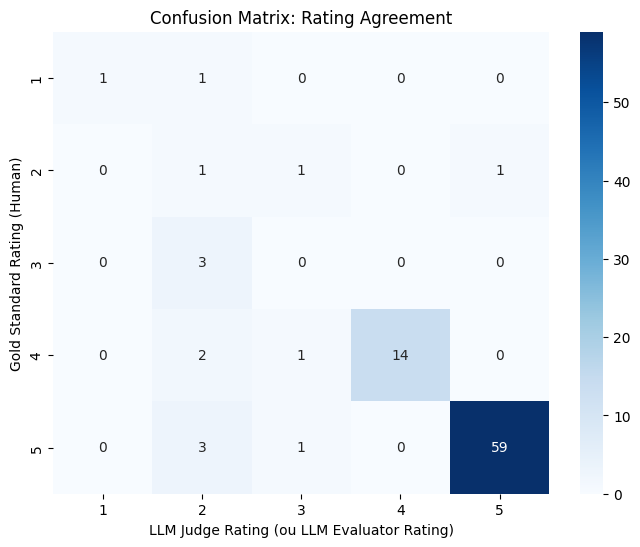

In [13]:
def analisar_performance(df):
    # 1. Índice Kappa de Cohen
    kappa = cohen_kappa_score(df['score_gold_standard'], df['score_llm_judge'])
    print(f"--- Índice Kappa de Cohen: {kappa:.3f} ---")

    # 2. Diferença de Médias (Viés do Juiz)
    diff_recall = df['recall_llm_judge'].mean() - df['recall_gold_standard'].mean()
    diff_precision = df['precision_llm_judge'].mean() - df['precision_gold_standard'].mean()

    print(f"\n--- Viés no Recall (LLM - Humano): {diff_recall:.3f} ---")
    print(f"Recall Médio (LLM): {df['recall_llm_judge'].mean():.3f}")
    print(f"Recall Médio (Humano): {df['recall_gold_standard'].mean():.3f}")

    print(f"\n--- Viés na Precision (LLM - Humano): {diff_precision:.3f} ---")
    print(f"Precision Média (LLM): {df['precision_llm_judge'].mean():.3f}")
    print(f"Precision Média (Humano): {df['precision_gold_standard'].mean():.3f}")

    # 3. Matriz de Confusão (Visual)
    cm = confusion_matrix(df['score_gold_standard'], df['score_llm_judge'], labels=[1, 2, 3, 4, 5])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
    plt.xlabel('LLM Judge Rating (ou LLM Evaluator Rating)')
    plt.ylabel('Gold Standard Rating (Human)')
    plt.title('Confusion Matrix: Rating Agreement')
    plt.show()

# Executar
df_evaluation_v2 = df_evaluation.copy()
df_evaluation_v2.loc[(df_evaluation_v2['score_gold_standard'] == 5) & (df_evaluation_v2['score_llm_judge'] == 4), 'score_gold_standard'] = 4

analisar_performance(df_evaluation_v2)

In [14]:
df_evaluation[(df_evaluation['score_gold_standard'] == 5) & (df_evaluation['score_llm_judge'] == 4)]

,nct_id,recall_llm_judge,precision_llm_judge,score_llm_judge,justification_llm_judge,recall_gold_standard,precision_gold_standard,score_gold_standard
26,NCT00871260,1.0,1.0,4.0,All inclusion and exclusion criteria are prese...,1.0,1.0,5
33,NCT03672591,1.0,1.0,4.0,All inclusion and exclusion criteria from the ...,1.0,1.0,5
34,NCT02349997,1.0,1.0,4.0,All inclusion and exclusion criteria from the ...,1.0,1.0,5
39,NCT01225094,1.0,1.0,4.0,All inclusion and exclusion criteria from the ...,1.0,1.0,5
41,NCT02227810,1.0,1.0,4.0,All inclusion and exclusion criteria from the ...,1.0,1.0,5
46,NCT03923530,1.0,1.0,4.0,All inclusion and exclusion criteria from the ...,1.0,1.0,5
54,NCT01648634,1.0,1.0,4.0,All inclusion and exclusion criteria are prese...,1.0,1.0,5
56,NCT04686604,1.0,1.0,4.0,All inclusion and exclusion criteria from the ...,1.0,1.0,5
60,NCT02831608,1.0,1.0,4.0,The extracted criteria capture all original in...,1.0,1.0,5
72,NCT02068040,1.0,1.0,4.0,All inclusion and exclusion criteria from the ...,1.0,1.0,5


In [15]:
print("\n--- Avaliação de todas as extrações: ---")
print(f"Quantidade de Extrações avaliadas: {metrics_all_llm_judge_df.shape[0]}")
print(f"Recall Médio (LLM): {metrics_all_llm_judge_df['recall_llm_judge'].mean():.3f}")
print(f"Precision Média (LLM): {metrics_all_llm_judge_df['precision_llm_judge'].mean():.3f}")
print(f"Nota média das extrações: {metrics_all_llm_judge_df['score_llm_judge'].mean():.3f}")


--- Avaliação de todas as extrações: ---
Quantidade de Extrações avaliadas: 1000
Recall Médio (LLM): 0.975
Precision Média (LLM): 0.980
Nota média das extrações: 4.385
